# INTR0DUCTION
This project analysis healthcare patient data to identify common diseases.

# IMPORT LIBRARIES

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



 # LOAD DATASET

In [6]:


df = pd.read_csv(r"C:\Users\HP\Downloads\healthcare_dataset.csv\healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


# DATA OVERVIEW

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [8]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


# DATA CLEANING

In [9]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['Gender'] = df['Gender'].str.lower()
df['Gender'] = df['Gender'].replace({'m': 'male', 'f': 'female'})

# FEATURES

In [12]:
bins = [0, 18, 35, 50, 65, 100]
labels = ['Child', 'Young', 'Adult', 'Middle Age', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

 # EDA

In [13]:
MedicalCondition_count = df['Medical Condition'].value_counts()
print(MedicalCondition_count)

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64


In [15]:
gender_MedicalCondition = pd.crosstab(df['Gender'], df['Medical Condition'])
print(gender_MedicalCondition)

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Gender                                                                       
female                  4642    4511    4566      4609          4569     4573
male                    4576    4584    4574      4607          4582     4573


In [16]:
age_MedicalCondition = pd.crosstab(df['Age_Group'], df['Medical Condition'])
print(age_MedicalCondition)

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Age_Group                                                                    
Child                    149     150     146       140           143      158
Young                   2262    2266    2271      2219          2234     2267
Adult                   2062    1983    1986      2094          2011     2031
Middle Age              2029    1978    2053      2087          2048     2103
Senior                  2716    2718    2684      2676          2715     2587


# HIGH RISK GROUP ANALYSIS

In [20]:
high_risk = df.groupby(['Age_Group', 'Medical Condition'],observed=True).size().sort_values(ascending=False)
print(high_risk.head())

Age_Group  Medical Condition
Senior     Asthma               2718
           Arthritis            2716
           Hypertension         2715
           Cancer               2684
           Diabetes             2676
dtype: int64


# VISUALISATION

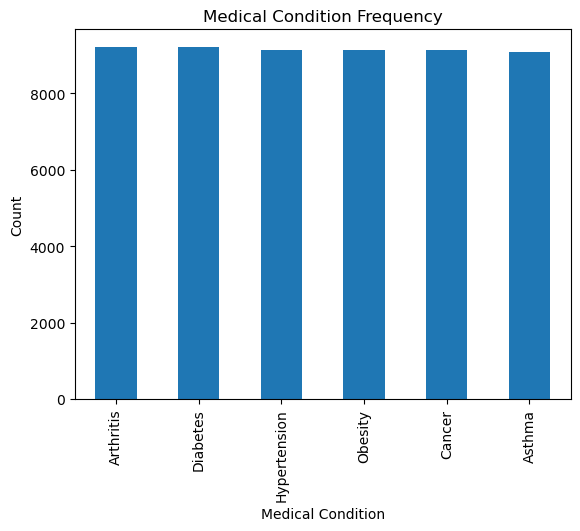

In [23]:

MedicalCondition_count.plot(kind='bar')
plt.title("Medical Condition Frequency")
plt.xlabel("Medical Condition")
plt.ylabel("Count")
plt.show()

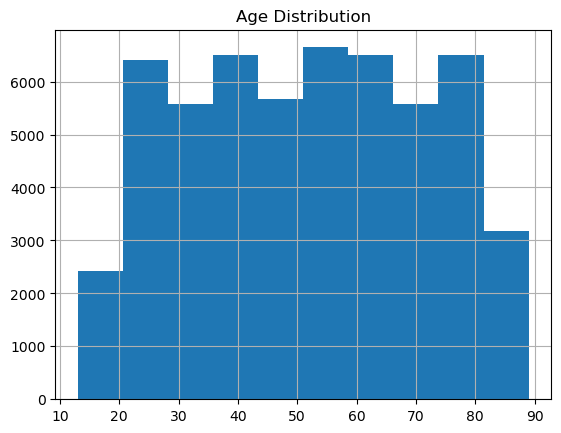

In [24]:
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

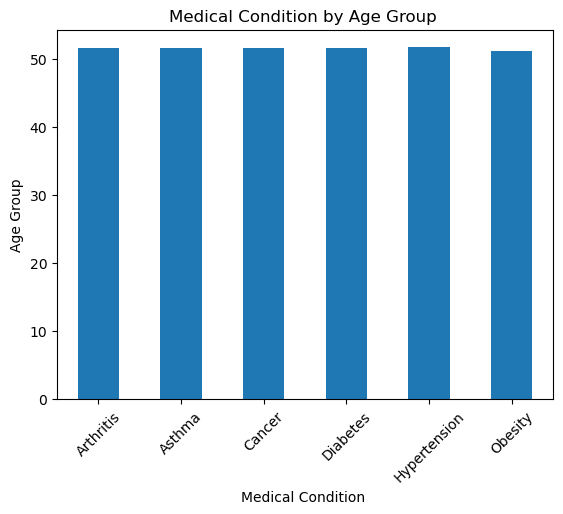

In [31]:
avg_age =df.groupby('Medical Condition')['Age'].mean()
avg_age.plot(kind='bar')
plt.title("Medical Condition by Age Group ")
plt.xlabel("Medical Condition ")
plt.ylabel("Age Group")
plt.xticks(rotation=45)
plt.show()

# KEYPOINTS

# The most common Medical Condition are  Asthma and Arthritis


# CONCLUSION 
The analysis shows that Medical Condition has a clear increse with age so i conclude it here.